# Conditional Monte Carlo for a density

Author: Fred J. Hickernell

Conditioning gives an analytic conditional CDF and density. It reduces variance for CDF estimation and gives a direct density estimator for IID Monte Carlo and randomized low discrepancy points.

Run with the course `qmcpy` kernel, or open a private working copy in Colab:

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fjhickernell/MATH565Fall2026/blob/main/notebooks/sampling/ConditionalMonteCarlo.ipynb)

In Colab, run the setup cell once and then continue in order. Save a copy in Drive to keep your changes.

$\newcommand{\vX}{\boldsymbol{X}}$

In [1]:
from pathlib import Path
import shutil
import subprocess
import sys
import time

NOTEBOOK_START_TIME = time.perf_counter()

colab = "google.colab" in sys.modules
if colab:
    print("Setting up this course's recorded classlib, QMCPy, and TeX; this may take several minutes …")
    course_checkout = Path("/content/MATH565Fall2026")
    if not course_checkout.exists():
        subprocess.run(
            [
                "git", "clone", "--quiet", "--depth", "1",
                "https://github.com/fjhickernell/MATH565Fall2026.git",
                str(course_checkout),
            ],
            check=True,
        )
    subprocess.run(
        [
            "git", "-C", str(course_checkout),
            "-c", "submodule.classlib.url=https://github.com/fjhickernell/HickernellAcademicLib.git",
            "-c", "submodule.qmcpy.url=https://github.com/QMCSoftware/qmcpy.git",
            "submodule", "update", "--init", "classlib", "qmcpy",
        ],
        check=True,
    )
    if shutil.which("latex") is None:
        subprocess.run(
            [
                "apt-get", "-qq", "install", "-y",
                "cm-super", "dvipng", "texlive-latex-extra",
                "texlive-latex-recommended",
            ],
            check=True,
        )
    subprocess.run(
        [
            sys.executable, "-m", "pip", "install", "-q",
            str(course_checkout / "classlib"),
            str(course_checkout / "qmcpy"),
        ],
        check=True,
    )
    print("Colab setup complete.")
    print("For faster repeated work, use the local `qmcpy` environment.")

## A weighted sum of uniforms

Let $Y=\sum_{j=1}^d w_j X_j$ for independent $X_j\sim\operatorname{Unif}(0,1)$ and positive weights. Given $X_2,\ldots,X_d$, the conditional density at $y$ is
$$
g_y(X_2,\ldots,X_d)=\frac1{w_1}\mathbf1\left\{0\le y-\sum_{j=2}^d w_jX_j\le w_1\right\}.
$$
Thus $\rho_Y(y)=\mathbb E[g_y(X_2,\ldots,X_d)]$. We have integrated out $X_1$. The choice of which coordinate to condition on matters.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from classlib.distributions import UniformSumDistribution

%matplotlib inline

def conditional_density(y, u, weights):
    weights = np.asarray(weights,float)
    tail = u @ weights[1:]
    return ((y[None,:]-tail[:,None] >= 0) &
            (y[None,:]-tail[:,None] <= weights[0])).mean(axis=0)/weights[0]

def exact_density(y, weights):
    return UniformSumDistribution.from_weights(weights).pdf(y)

## Compare IID and randomized Sobol

Both sample means estimate the same density. The classlib distribution supplies a reference curve for this example.

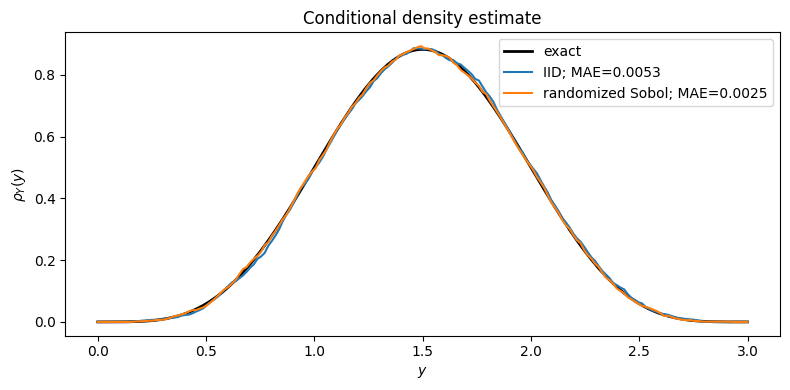

In [3]:
weights = np.array([1.0, 0.8, 0.6, 0.4, 0.2])
n = 2**10
y = np.linspace(0, weights.sum(), 180)
truth = exact_density(y, weights)
rng = np.random.default_rng(565)
u_iid = rng.random((n,len(weights)-1))
u_sobol = qmc.Sobol(len(weights)-1, scramble=True, seed=565).random_base2(10)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(y,truth,'k',lw=2,label="exact")
for label,u in [("IID",u_iid),("randomized Sobol",u_sobol)]:
    estimate=conditional_density(y,u,weights)
    mae=np.mean(np.abs(estimate-truth))
    ax.plot(y,estimate,label=f"{label}; MAE={mae:.4f}")
ax.set(xlabel="$y$",ylabel=r"$\rho_Y(y)$",title="Conditional density estimate")
ax.legend(); fig.tight_layout()
assert np.all(np.isfinite(truth))

## Which coordinate should we integrate out?

The density is unchanged if we reorder the weights. Compare estimates across independent replications for two choices of $w_1$.

In [4]:
orderings = {"largest first":weights, "smallest first":weights[::-1]}
repetitions=20
for name,w in orderings.items():
    errors=[]
    for rep in range(repetitions):
        u=np.random.default_rng(1000+rep).random((n,len(w)-1))
        errors.append(np.mean(np.abs(conditional_density(y,u,w)-truth)))
    print(f"{name:15s}: mean absolute density error {np.mean(errors):.5f}")

largest first  : mean absolute density error 0.00683
smallest first : mean absolute density error 0.02556


Conditioning reduces the variance of a **CDF** estimator because a conditional expectation has no more variance than the original indicator. Differentiating the analytic conditional CDF yields the density estimate above, without choosing a histogram bandwidth. Its error still depends on the weights, the conditioned coordinate, and the sample design.

In [5]:
notebook_elapsed = time.perf_counter() - NOTEBOOK_START_TIME
notebook_minutes, notebook_seconds = divmod(notebook_elapsed, 60)
print(
    "Total execution time for this notebook is "
    f"{int(notebook_minutes)} min {notebook_seconds:.1f} sec."
)

Total execution time for this notebook is 0 min 0.9 sec.
